In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("/Users/zolbur13/Downloads/Integrated.csv")
df

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,instrumentalness,liveness,valence,tempo,track_genre,ArtistFamiliarity,Hotness,end_of_fade_in,Loudness,start_of_fade_out
0,0,6dwkFmLUz6hx2CZG2EqLol,Howie Day,Stop All The World Now,Collide,66,249120,False,0.636,0.625,...,0.000053,0.1190,0.3420,93.931,acoustic,0.830642,0.546054,0.078,-12.316,268.011
1,1,3bat14NdN3flvcsEMpVOFq,Black Messiah,First War of the World,Gullveig,20,488533,False,0.558,0.969,...,0.073500,0.3340,0.5410,124.019,black-metal,0.506776,0.427798,0.000,-5.461,480.885
2,2,6ZiaGtb94L6LtRbC3yHkJW,Old Man's Child,In Defiance of Existence,Life Deprived,18,289346,False,0.183,0.887,...,0.893000,0.3560,0.1500,157.824,black-metal,0.635483,0.428442,0.217,-5.520,285.896
3,3,3e0tyTV5FiV1bcYeRjdDz2,Moonspell,Sin / Pecado,The Hanged Man,18,386333,False,0.404,0.636,...,0.653000,0.0795,0.0979,140.105,black-metal,0.722571,0.499826,0.177,-8.087,386.194
4,4,0zTdT65lUqepmx7N5dwVRj,Moonspell,Lisboa Under the Spell,Alma Mater,17,411506,False,0.337,0.955,...,0.891000,0.8620,0.1510,142.457,black-metal,0.722571,0.499826,0.000,-5.255,307.345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,128,4J0phvYcKa1Hr1EBwH0pu3,Los Auténticos Decadentes,Supersonico,Qué Vas a Hacer Conmigo,37,206933,False,0.615,0.586,...,0.000001,0.1450,0.7630,130.221,ska,0.610331,0.407822,0.000,-5.634,205.374
129,129,3KwxfGupNXVbQnRz0FkOPp,Los Fabulosos Cadillacs,Originales - 20 Exitos,"Manuel Santillán, el León - Versión Reggae",37,236066,False,0.771,0.902,...,0.000062,0.3320,0.9550,107.617,ska,0.774037,0.521727,0.178,-4.879,234.144
130,130,4wN3FpTUeX142D60F23AEZ,Simple Minds,Once Upon A Time (Super Deluxe),Sanctify Yourself - Edit,26,234133,False,0.531,0.948,...,0.000025,0.7510,0.5950,128.096,synth-pop,0.700680,0.503362,1.040,-11.231,413.222
131,131,3CjQAbOyux9kiLgO98N6Ff,Simple Minds,Once Upon A Time,Sanctify Yourself - Remastered 2002,25,297453,False,0.564,0.912,...,0.000669,0.6720,0.7240,128.219,synth-pop,0.700680,0.503362,1.040,-11.231,413.222


In [4]:
df[['energy','key', 'loudness', 'mode', 'speechiness', 'acousticness']]

,energy,key,loudness,mode,speechiness,acousticness
0,0.625,11,-7.895,1,0.0277,0.222000
1,0.969,9,-5.069,1,0.0649,0.001240
2,0.887,1,-5.990,1,0.0580,0.000003
3,0.636,4,-8.798,0,0.0325,0.064300
4,0.955,9,-5.061,0,0.0839,0.000006
...,...,...,...,...,...,...
128,0.586,0,-9.846,1,0.0339,0.163000
129,0.902,7,-1.598,0,0.0290,0.236000
130,0.948,0,-5.265,1,0.0533,0.277000
131,0.912,0,-6.055,1,0.0411,0.066100


In [5]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'track_genre',
       'ArtistFamiliarity', 'Hotness', 'end_of_fade_in', 'Loudness',
       'start_of_fade_out'],
      dtype='object')

/var/folders/2y/t1t731511xz90vz0q_kmhbdw0000gn/T/ipykernel_59931/43157858.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_means.index, y=genre_means.values, palette="rainbow")


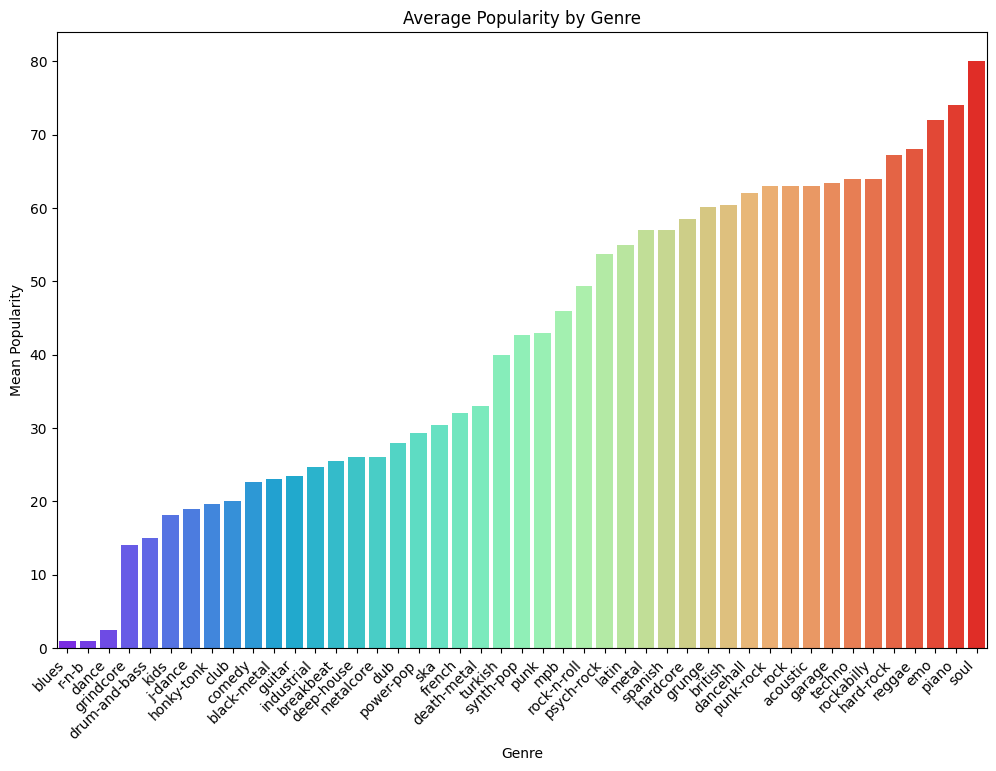

In [11]:

# Shows which genres are on average more popularity
genre_means = df.groupby("track_genre")["popularity"].mean().sort_values()

plt.figure(figsize=(12, 8))
sns.barplot(x=genre_means.index, y=genre_means.values, palette="rainbow")
plt.xticks(rotation=45, ha='right')
plt.title("Average Popularity by Genre")
plt.ylabel("Mean Popularity")
plt.xlabel("Genre")
plt.show()

In [12]:
#What makes hit songs different from non hits
import numpy as np

threshold = df['popularity'].quantile(0.95)

df['is_hit'] = df['popularity'] >= threshold




In [13]:
hit_summary = df.groupby("is_hit")[[
    "energy", "danceability", "loudness", "tempo", "acousticness",
    "instrumentalness", "liveness", "valence", "speechiness"
]].mean().T

print(hit_summary)

is_hit                 False       True 
energy              0.699484    0.719429
danceability        0.543008    0.647571
loudness           -7.998722   -7.707286
tempo             122.395071  109.360714
acousticness        0.218661    0.154913
instrumentalness    0.117884    0.014248
liveness            0.242341    0.102843
valence             0.537763    0.529000
speechiness         0.093163    0.066443


Hits have more energy, danceability, loudness. Slower tempo, less acousticness

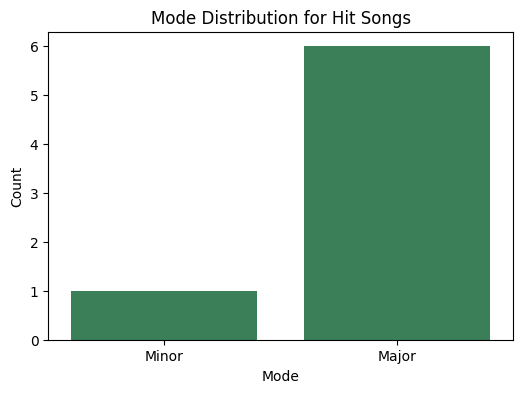

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(data=hits, x="mode", color="seagreen")
plt.title("Mode Distribution for Hit Songs")
plt.xticks([0, 1], ["Minor", "Major"])
plt.xlabel("Mode")
plt.ylabel("Count")
plt.show()

Top songs are generally major